# Chapter 4 — Antennas & Receivers

In [Chapter 3](03_signals_noise_radiometer.ipynb) we treated the telescope as a
black box that delivers band-limited noise, and the radiometer equation told us how
quickly a signal climbs out of that noise. But two black-box numbers were smuggled in
without explanation: *how much* of the sky does the antenna actually see (its **beam**),
and *how well* does it convert incoming flux into measurable power (its **effective
area**)? This chapter opens the box.

An antenna is a **diffraction-limited optical instrument** that happens to work at
centimetre and metre wavelengths instead of optical ones. Because radio wavelengths are
$10^5$–$10^6$ times longer than visible light, a radio dish has *terrible* angular
resolution for its size — which is why radio dishes are enormous, and why radio
astronomers eventually had to invent interferometry (Chapter 8) to do any better.

## What you'll learn

- The antenna **power pattern**: the main lobe, the half-power beamwidth (FWHM), and the
  sidelobes — and why a uniformly illuminated dish produces an **Airy pattern**.
- **Angular resolution** and the diffraction limit $\theta \approx 1.22\,\lambda/D$, the
  same formula that governs an optical telescope or a camera lens.
- **Effective area** $A_\mathrm{eff}$, antenna **gain**, and **aperture efficiency**
  $\eta$, with $A_\mathrm{eff} = \eta\,\pi D^2/4$.
- How collecting area sets sensitivity through the **system equivalent flux density**,
  $\mathrm{SEFD} = 2k_B T_\mathrm{sys} / A_\mathrm{eff}$, and the figure of merit
  $G/T$.

We will work a concrete example throughout: a **25 m dish observing the 21 cm
hydrogen line at 1.4 GHz** — roughly a single antenna of the VLA or the Westerbork array.

## The references

There is no single "discovery paper" for antenna theory — it grew out of the optics of
Airy and Rayleigh in the 19th century and the radar engineering of the 1940s. The two
standing references for everything in this chapter are:

> **Condon, J. J. & Ransom, S. M.** *Essential Radio Astronomy.* Princeton University
> Press, 2016. Chapter 3 ("Radio Telescopes and Radiometers").
> Free online: [cv.nrao.edu/~sransom/web/Ch3.html](https://www.cv.nrao.edu/~sransom/web/Ch3.html)

> **Wilson, T. L., Rohlfs, K. & Hüttemeister, S.** *Tools of Radio Astronomy*
> (6th ed., Springer, 2013). Chapters 5–7. [DOI: 10.1007/978-3-642-39950-3](https://doi.org/10.1007/978-3-642-39950-3)

The diffraction limit itself traces to:

> **Airy, G. B. (1835).** *On the Diffraction of an Object-glass with Circular Aperture.*
> Trans. Cambridge Phil. Soc. **5**, 283. — The Airy pattern and the first dark ring.

> **Lord Rayleigh (1879).** *Investigations in optics, with special reference to the
> spectroscope.* Phil. Mag. **8**, 261. — The Rayleigh criterion for resolving two
> point sources.

Condon & Ransom is the one to keep open beside this notebook: every formula below appears
there, usually with a clearer derivation than we have room for here.

## The physics

### The antenna as a Fourier transform

A fundamental result of diffraction theory: the **far-field radiation pattern** of an
aperture is the (squared magnitude of the) **Fourier transform of the aperture
illumination**. A radio dish with a circular, uniformly illuminated aperture of diameter
$D$ therefore radiates — and, by reciprocity, *receives* — with the classic **Airy
pattern**:

$$ P(\theta) \;=\; \left[\frac{2 J_1(x)}{x}\right]^2,
   \qquad x \;=\; \frac{\pi D}{\lambda}\sin\theta, $$

where $J_1$ is the first-order Bessel function and $\theta$ is the angle off boresight.
This is exactly what `jansky.signals.airy_beam` evaluates. The pattern has a bright
**main lobe** surrounded by progressively fainter **sidelobes**, the first of which peaks
at only $-17.6$ dB (about 1.7% of the main-lobe power).

### The first null and the resolution limit

The first dark ring of the Airy pattern — the first null of $J_1(x)$ — occurs at
$x = 3.8317$, i.e. when

$$ \sin\theta_\mathrm{null} \;=\; 1.220\,\frac{\lambda}{D}. $$

The factor $3.8317/\pi = 1.220$ is the origin of the famous **$1.22\,\lambda/D$**. By the
**Rayleigh criterion**, two point sources are *just resolved* when one sits on the first
null of the other, so the angular resolution of a filled circular aperture is

$$ \boxed{\;\theta_\mathrm{res} \;\approx\; 1.22\,\frac{\lambda}{D}\;}. $$

In practice dishes are *tapered* (illuminated more weakly at the edge to suppress
sidelobes), which widens the main beam slightly; the **half-power beamwidth** (FWHM) of a
real dish is usually written $\theta_\mathrm{FWHM} \approx k\,\lambda/D$ with
$k \approx 1.0$–$1.3$. For a uniformly illuminated aperture the Airy main lobe has
$\theta_\mathrm{FWHM} \approx 1.029\,\lambda/D$.

### Effective area, gain, and aperture efficiency

An antenna pointed at a source of flux density $S$ (W m$^{-2}$ Hz$^{-1}$) collects a power
per unit bandwidth of $\tfrac{1}{2} A_\mathrm{eff} S$ (the $\tfrac12$ because a single
receiver chain measures one polarisation). The **effective area** is smaller than the
geometric area $A_\mathrm{geom} = \pi D^2/4$ by the **aperture efficiency** $\eta$:

$$ A_\mathrm{eff} \;=\; \eta \,\frac{\pi D^2}{4}, \qquad 0 < \eta \lesssim 1. $$

Typical dishes achieve $\eta \approx 0.5$–$0.7$, the shortfall coming from illumination
taper, surface roughness, blockage by the feed legs, and spillover. Effective area and the
beam solid angle $\Omega_A$ are tied together by the **antenna theorem**
$A_\mathrm{eff}\,\Omega_A = \lambda^2$.

### From area to sensitivity: SEFD and G/T

The **antenna temperature** produced by a source of flux density $S$ is
$T_A = A_\mathrm{eff} S / (2 k_B)$. A source is detectable when $T_A$ rivals the system
temperature $T_\mathrm{sys}$; the flux density that produces $T_A = T_\mathrm{sys}$ is the
**system equivalent flux density**:

$$ \boxed{\;\mathrm{SEFD} \;=\; \frac{2 k_B T_\mathrm{sys}}{A_\mathrm{eff}}\;}. $$

SEFD (in janskys) is the single most useful sensitivity figure of merit for a telescope:
small is good. Combined with the radiometer equation, the $1\sigma$ flux sensitivity of a
single dish in time $\tau$ over bandwidth $B$ is
$\Delta S = \mathrm{SEFD}/\sqrt{n_\mathrm{pol} B \tau}$. The closely related engineering
figure of merit is the **gain-to-noise-temperature ratio**
$G/T \propto A_\mathrm{eff}/T_\mathrm{sys}$, which is just the inverse of SEFD up to
constants.

## Setting up

We'll lean on two beam helpers from `jansky.signals`:

- `airy_beam(theta, diameter, wavelength)` — the Airy power pattern of a uniformly
  illuminated circular dish, in radians off boresight.
- `gaussian_beam(theta, fwhm)` — a Gaussian beam, a common analytic stand-in for the
  main lobe of a real (tapered) dish.

Everything physical is carried in `astropy.units` so the dimensional bookkeeping is
automatic, and we call `plotting.use_jansky_style()` so the figures match the rest of the
course.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.constants import k_B, c
from scipy import special

from jansky import signals, plotting

plotting.use_jansky_style()

# Our running example: a 25 m dish at the 21 cm HI line.
D = 25 * u.m
freq = 1.4 * u.GHz
wavelength = (c / freq).to(u.m)   # lambda = c / nu

print(f"Dish diameter      D = {D}")
print(f"Frequency          nu = {freq}")
print(f"Wavelength         lambda = {wavelength:.4f}")

Dish diameter      D = 25.0 m
Frequency          nu = 1.4 GHz
Wavelength         lambda = 0.2141 m


## The beam pattern: main lobe and sidelobes

Let's plot the Airy power pattern of our 25 m dish on a **decibel** scale, where the
faint sidelobes become visible, and overlay a Gaussian beam matched to the same FWHM. The
first null — the $1.22\,\lambda/D$ point — is marked explicitly.

first null  theta_null = 35.924 arcmin
Airy FWHM   theta_FWHM = 30.300 arcmin


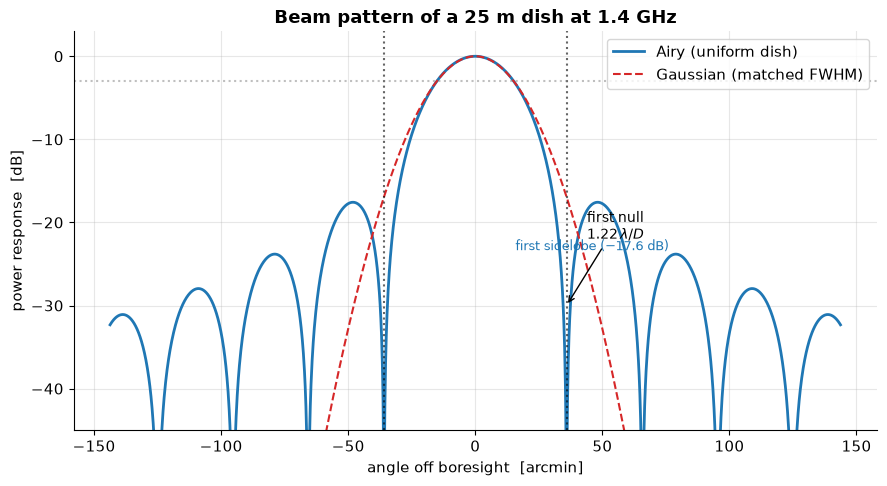

In [2]:
# First-null half-angle: sin(theta) = 1.22 lambda / D  (small angle => theta ~ 1.22 l/D).
theta_null = (1.220 * wavelength / D).to(u.dimensionless_unscaled).value * u.rad
# Airy main-lobe FWHM for a uniform aperture: 1.029 lambda / D.
theta_fwhm_airy = (1.029 * wavelength / D).to(u.dimensionless_unscaled).value * u.rad

print(f"first null  theta_null = {theta_null.to(u.arcmin):.3f}")
print(f"Airy FWHM   theta_FWHM = {theta_fwhm_airy.to(u.arcmin):.3f}")

# Angular grid, a few beamwidths wide, in radians for the helper calls.
theta = np.linspace(-4 * theta_null.value, 4 * theta_null.value, 2000)  # rad

airy = signals.airy_beam(theta, D.to(u.m).value, wavelength.to(u.m).value)
gauss = signals.gaussian_beam(theta, theta_fwhm_airy.value)

# Convert to dB (clip the zeros at the nulls so log is finite).
airy_db = 10 * np.log10(np.clip(airy, 1e-6, None))
gauss_db = 10 * np.log10(np.clip(gauss, 1e-6, None))
theta_arcmin = (theta * u.rad).to(u.arcmin).value

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(theta_arcmin, airy_db, color="#1f77b4", lw=2, label="Airy (uniform dish)")
ax.plot(theta_arcmin, gauss_db, color="#d62728", lw=1.5, ls="--", label="Gaussian (matched FWHM)")

for sign in (-1, 1):
    ax.axvline(sign * theta_null.to(u.arcmin).value, color="k", ls=":", alpha=0.6)
ax.axhline(-3, color="grey", ls=":", alpha=0.5)
ax.annotate("first null\n$1.22\\,\\lambda/D$",
            xy=(theta_null.to(u.arcmin).value, -30),
            xytext=(theta_null.to(u.arcmin).value + 8, -22),
            arrowprops=dict(arrowstyle="->", color="k"), fontsize=10)
ax.annotate("first sidelobe ($-17.6$ dB)", xy=(0, -17.6), xytext=(0.55, 0.45),
            textcoords="axes fraction", fontsize=9, color="#1f77b4")

ax.set_xlabel(r"angle off boresight  [arcmin]")
ax.set_ylabel("power response  [dB]")
ax.set_title(f"Beam pattern of a {D:.0f} dish at {freq:.1f}")
ax.set_ylim(-45, 3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

The Airy pattern's main lobe is the part we observe with; the sidelobes are a nuisance,
letting in radiation (and interference, and ground noise) from well off-axis. The
first-null markers sit exactly at $\pm 1.22\,\lambda/D$, and the Gaussian approximation
tracks the main lobe well but knows nothing of the sidelobes — a reminder that the
Gaussian is only a model of the central beam.

Let's confirm the sidelobe level and the position of the first null numerically against
the Bessel-function theory.

In [3]:
# The first null of J1 is at x = 3.8317; the first sidelobe peak is near x = 5.1356.
x_null = special.jn_zeros(1, 1)[0]
print(f"first zero of J1:              x = {x_null:.4f}  (=> 1.22 factor = {x_null/np.pi:.4f})")

# Peak of the first sidelobe of the Airy pattern.
x = np.linspace(x_null + 0.1, 8, 5000)
sidelobe = (2 * special.j1(x) / x) ** 2
x_peak = x[np.argmax(sidelobe)]
peak_db = 10 * np.log10(sidelobe.max())
print(f"first sidelobe peak:           x = {x_peak:.3f}, level = {peak_db:.1f} dB")
print(f"                               (textbook value: -17.6 dB)")

assert np.isclose(x_null / np.pi, 1.2197, atol=1e-3)
print("\nThe 1.22 factor and -17.6 dB sidelobe are reproduced.")

first zero of J1:              x = 3.8317  (=> 1.22 factor = 1.2197)
first sidelobe peak:           x = 5.135, level = -17.6 dB
                               (textbook value: -17.6 dB)

The 1.22 factor and -17.6 dB sidelobe are reproduced.


## Angular resolution of a real dish

Now the headline number: what can a 25 m dish actually resolve at 1.4 GHz? We compute the
diffraction limit $1.22\,\lambda/D$ with full units, and compare it to the FWHM.

In [4]:
def resolution(diameter, frequency, factor=1.22):
    '''Diffraction-limited resolution theta = factor * lambda / D, with units.

    Parameters
    ----------
    diameter : ~astropy.units.Quantity
        Dish diameter (length).
    frequency : ~astropy.units.Quantity
        Observing frequency.
    factor : float
        1.22 for the Rayleigh/first-null limit; ~1.0 for the FWHM.
    '''
    lam = (c / frequency).to(u.m)
    theta = (factor * lam / diameter).to(u.dimensionless_unscaled).value * u.rad
    return theta.to(u.arcmin)


theta_res = resolution(D, freq)                 # Rayleigh / first-null
theta_fwhm = resolution(D, freq, factor=1.029)  # Airy main-lobe FWHM

print(f"25 m @ 1.4 GHz:")
print(f"  Rayleigh limit (1.22 l/D):  {theta_res:.3f}  = {theta_res.to(u.deg):.3f}")
print(f"  Airy FWHM      (1.03 l/D):  {theta_fwhm:.3f}")
print()
print(f"For scale, the full Moon is about 30 arcmin across, so this single dish")
print(f"smears the Moon into roughly {(30*u.arcmin / theta_fwhm).to(u.dimensionless_unscaled):.0f} resolution elements.")

25 m @ 1.4 GHz:
  Rayleigh limit (1.22 l/D):  35.924 arcmin  = 0.599 deg
  Airy FWHM      (1.03 l/D):  30.300 arcmin

For scale, the full Moon is about 30 arcmin across, so this single dish
smears the Moon into roughly 1 resolution elements.


## From collecting area to SEFD

Finally, the sensitivity chain. We take a realistic aperture efficiency $\eta = 0.6$ and a
modern system temperature $T_\mathrm{sys} = 30$ K, compute the effective area, and convert
it to a system equivalent flux density in janskys.

In [5]:
eta = 0.6                 # aperture efficiency (illumination, surface, blockage, spillover)
T_sys = 30 * u.K          # cryogenic L-band receiver

A_geom = np.pi * D**2 / 4
A_eff = eta * A_geom

# SEFD = 2 k_B T_sys / A_eff.  k_B has units J/K = W/(Hz K), so SEFD comes out in W/m^2/Hz.
SEFD = (2 * k_B * T_sys / A_eff).to(u.Jy)

print(f"geometric area   A_geom = {A_geom:.1f}")
print(f"effective area   A_eff  = {A_eff:.1f}   (eta = {eta})")
print(f"system temp      T_sys  = {T_sys}")
print(f"SEFD                     = {SEFD:.0f}")
print()

# Cross-check: antenna temperature from a 1 Jy source.
S = 1 * u.Jy
T_A = (A_eff * S / (2 * k_B)).to(u.K)
print(f"A 1 Jy source raises the antenna temperature by T_A = {T_A:.4f}")
print(f"  (so a source equal to SEFD = {SEFD.to(u.Jy):.0f} would give T_A = T_sys)")

geometric area   A_geom = 490.9 m2
effective area   A_eff  = 294.5 m2   (eta = 0.6)
system temp      T_sys  = 30.0 K
SEFD                     = 281 Jy

A 1 Jy source raises the antenna temperature by T_A = 0.1067 K
  (so a source equal to SEFD = 281 Jy would give T_A = T_sys)


The SEFD ties the abstract radiometer equation of Chapter 3 to a real instrument: with the
SEFD in hand, the $1\sigma$ flux sensitivity after integrating for time $\tau$ over
bandwidth $B$ with both polarisations is simply
$\Delta S = \mathrm{SEFD}/\sqrt{2 B \tau}$. Let's evaluate it for a typical L-band setup.

In [6]:
B = 100 * u.MHz
tau = 1 * u.hour
n_pol = 2

dS = (SEFD / np.sqrt(n_pol * B * tau)).to(u.uJy)
print(f"1-sigma sensitivity after {tau} over {B}: Delta_S = {dS:.2f}")
print(f"  (={dS.to(u.mJy):.4f} per beam)")

# G/T figure of merit (proportional to A_eff / T_sys, the inverse of SEFD).
G_over_T = (A_eff / T_sys).to(u.m**2 / u.K)
print(f"\nG/T figure of merit ~ A_eff/T_sys = {G_over_T:.2f}")

1-sigma sensitivity after 1.0 h over 100.0 MHz: Delta_S = 331.47 uJy
  (=0.3315 mJy per beam)

G/T figure of merit ~ A_eff/T_sys = 9.82 m2 / K


## Try it yourself

The cells below are **scaffolds**: they run as-is and return placeholder values, but the
real work is left for you, marked with `# TODO`. Replace the stubbed return values with
real calculations using the helpers above (`resolution`, `signals.airy_beam`, the SEFD
formula). The notebook will still execute end-to-end before you do — the stubs just print a
clear "not implemented yet" note.

### Exercise 1 — Resolution of the VLA and a 100 m dish

The **VLA** in its most extended A-configuration has a maximum baseline of about
$B_\mathrm{max} = 36$ km; for an interferometer the resolution is set by the *baseline*
rather than the dish diameter, so use $\theta \approx 1.22\,\lambda/B_\mathrm{max}$. The
**GBT** (Green Bank Telescope) is a 100 m single dish.

Compute, at 1.4 GHz:
1. the resolution of the VLA-A (treat $B_\mathrm{max}$ in place of $D$), and
2. the resolution of the 100 m GBT,

and compare both to our 25 m dish. Which resolves the Moon (30 arcmin) into the most
elements?

In [7]:
def exercise_resolutions():
    '''TODO: compute resolutions at 1.4 GHz for the VLA-A and the GBT.

    Returns a dict mapping instrument name -> resolution (an astropy Quantity in arcmin).
    '''
    freq = 1.4 * u.GHz

    # TODO: use the `resolution(...)` helper defined above.
    #   - VLA-A: pass B_max = 36 km as the "diameter".
    #   - GBT:   pass D = 100 m.
    # TODO: replace the placeholder values below with the real calculations.
    results = {
        "VLA-A (36 km)": np.nan * u.arcmin,   # TODO
        "GBT (100 m)":   np.nan * u.arcmin,   # TODO
        "Our 25 m":      resolution(25 * u.m, freq),  # worked example, for comparison
    }
    return results


_res = exercise_resolutions()
for name, theta in _res.items():
    flag = "  <-- TODO (placeholder)" if not np.isfinite(theta.value) else ""
    print(f"{name:16s}: {theta:.4f}{flag}")

VLA-A (36 km)   : nan arcmin  <-- TODO (placeholder)
GBT (100 m)     : nan arcmin  <-- TODO (placeholder)
Our 25 m        : 35.9241 arcmin


### Exercise 2 — SEFD vs aperture efficiency and dish size

Sensitivity scales as $\mathrm{SEFD} \propto T_\mathrm{sys} / (\eta D^2)$. Build a small
study: for a fixed $T_\mathrm{sys} = 30$ K, compute the SEFD for dish diameters of 25 m,
64 m (Parkes), and 100 m (GBT) at $\eta = 0.6$, and see how a poorer efficiency
($\eta = 0.4$) inflates the SEFD. Plot SEFD vs diameter on log–log axes — it should be a
straight line of slope $-2$.

In [8]:
def exercise_sefd(diameter, eta=0.6, t_sys=30 * u.K):
    '''TODO: return the SEFD (in Jy) for a dish of the given diameter and efficiency.

    SEFD = 2 k_B T_sys / A_eff,  with  A_eff = eta * pi D^2 / 4.
    '''
    # TODO: implement using A_eff = eta * pi * diameter**2 / 4
    #       and SEFD = (2 * k_B * t_sys / A_eff).to(u.Jy).
    # Placeholder so the notebook runs:
    return np.nan * u.Jy


diameters = [25, 64, 100] * u.m
print("SEFD at eta = 0.6:")
for d in diameters:
    sefd = exercise_sefd(d)
    flag = "  <-- TODO (placeholder)" if not np.isfinite(sefd.value) else ""
    print(f"  D = {d:6.0f}: SEFD = {sefd:.0f}{flag}")

# TODO: once exercise_sefd is implemented, plot SEFD vs diameter on log-log axes
#       and confirm the slope is -2.

SEFD at eta = 0.6:
  D =     25 m: SEFD = nan Jy  <-- TODO (placeholder)
  D =     64 m: SEFD = nan Jy  <-- TODO (placeholder)
  D =    100 m: SEFD = nan Jy  <-- TODO (placeholder)


## Recap & what's next

We opened the telescope black box and met the two numbers that define a single dish:

- **The beam.** A uniformly illuminated circular aperture radiates an **Airy pattern**
  with a main lobe and $-17.6$ dB sidelobes. Its first null sits at $1.22\,\lambda/D$,
  giving the **diffraction-limited resolution** $\theta \approx 1.22\,\lambda/D$. For our
  25 m dish at 1.4 GHz that is about 0.7°, embarrassingly coarse — the long radio
  wavelength is the price of admission.
- **The area.** **Effective area** $A_\mathrm{eff} = \eta\,\pi D^2/4$ converts incoming
  flux to antenna temperature, and the **SEFD** $= 2 k_B T_\mathrm{sys}/A_\mathrm{eff}$
  folds collecting area and system temperature into a single sensitivity number in
  janskys. Combined with the radiometer equation, SEFD predicts the flux sensitivity of
  any integration.

The coarse single-dish resolution is exactly the problem **aperture synthesis** solves: by
combining many small dishes spread over kilometres, an interferometer synthesises the
resolution of an aperture as large as the array. That is the subject of
[Chapter 8](08_aperture_synthesis.ipynb) — where the $1.22\,\lambda/D$ of this chapter
returns as $1.22\,\lambda/B_\mathrm{max}$, with the *baseline* $B_\mathrm{max}$ standing in
for the dish diameter.